### Importation of the libraries 

In [77]:
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn 
%pip install scikit-learn 
%pip install torch 
%pip install scikit-optimize 
%pip install xgboost
%pip install openpyxl
%pip install tabulate
%pip install statsmodels
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

### Loading the Data

In [79]:
df = pd.read_excel("Pups_Analyse NTs_221124.xlsx", sheet_name="NT-R-stack")

<span style="color:yellow"> With the info command I have information about the data structure, including the number of rows, colums, data types and non-null values for each variables</span>

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Projet                108 non-null    object 
 1   Cohort                108 non-null    object 
 2   Group                 108 non-null    object 
 3   Cage                  60 non-null     object 
 4   ID                    81 non-null     object 
 5   ID.2                  81 non-null     object 
 6   Sample Name           108 non-null    object 
 7   Sex                   108 non-null    object 
 8   Area                  108 non-null    object 
 9   5HTP                  101 non-null    float64
 10  Adénosine             108 non-null    float64
 11  Adrénaline            3 non-null      float64
 12  Dopamine              67 non-null     float64
 13  GABA                  108 non-null    float64
 14  Glutamate             108 non-null    float64
 15  Glutamine aire brute  1

## Cleaning / Preparation / Visualisation of the Data

### Cleaning the Data 

<span style="color:yellow"> We decided that any data that have a : </span>  
<span style="color:red"> - Tyrosine value inferior to 15 </span>  
<span style="color:red"> - Tyramine value superior to 40 </span>  
<span style="color:yellow"> are considered as outliers: </span>

<span style="color:yellow"> Here's a representation of these outliers </span>

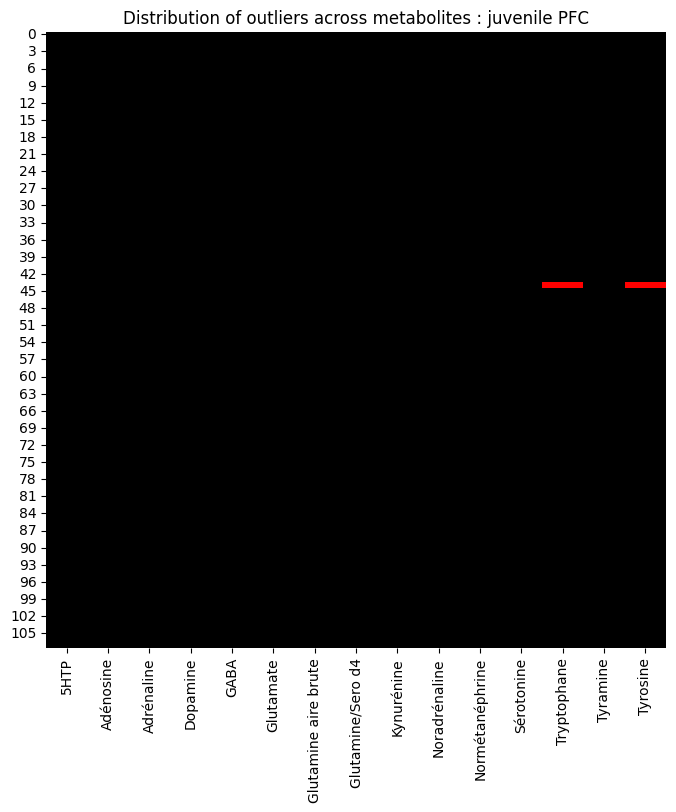

In [81]:
mask = (df["Tryptophane"] < 15) & (df["Tyrosine"] > 40)

outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
outlier_mask.loc[mask, ["Tryptophane", "Tyrosine"]] = True

nts = [
    "5HTP",
    "Adénosine",
    "Adrénaline",
    "Dopamine",
    "GABA",
    "Glutamate",
    "Glutamine aire brute",
    "Glutamine/Sero d4",
    "Kynurénine",
    "Noradrénaline",
    "Normétanéphrine",
    "Sérotonine",
    "Tryptophane",
    "Tyramine",
    "Tyrosine"
]

plt.figure(figsize=(8, 8))
sns.heatmap(
    outlier_mask[nts],
    #linewidths=0.05,
    cmap=["black", "red"],
    cbar=False
)
plt.title("Distribution of outliers across metabolites : juvenile PFC")
plt.show()

<span style="color:yellow"> For more information about that outlier  </span>

In [82]:
print(df.loc[mask])

   Projet    Cohort Group Cage ID ID.2    Sample Name     Sex Area  5HTP  ...  \
44  VEAVE  Cohort 1   LBN    C  5   C5  Souris_LBN C5  female  STR   NaN  ...   

    Glutamate  Glutamine aire brute  Glutamine/Sero d4  Kynurénine  \
44      2.564              42760000              138.4    0.000186   

    Noradrénaline  Normétanéphrine  Sérotonine  Tryptophane  Tyramine  \
44         0.1161           0.1624      0.1014        9.042    0.1323   

    Tyrosine  
44     40.78  

[1 rows x 24 columns]


<span style="color:yellow"> Now we remove that value </span>

In [83]:
df = df[
    ~(
        ((df['Tryptophane']<15) & (df['Tyrosine'] > 40))
    )
]
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

<span style="color:yellow"> So the different columns are : </span>

In [84]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine', 'GABA',
       'Glutamate', 'Glutamine aire brute', 'Glutamine/Sero d4', 'Kynurénine',
       'Noradrénaline', 'Normétanéphrine', 'Sérotonine', 'Tryptophane',
       'Tyramine', 'Tyrosine'],
      dtype='object')


### Separation of the Data by Area

<span style="color:yellow"> Here we seperate the data into 3 dataset : For the PFC, HIP, STR </span>

In [85]:
NT_df_pfc_juv = df.query("Area == 'PFC'").copy()
NT_df_hip_juv = df.query("Area == 'HIP'").copy()
NT_df_str_juv = df.query("Area == 'STR'").copy()



In [86]:
NT_df_pfc_juv.index = NT_df_pfc_juv.index + 1 # So now the index starts at 1 instead of 0
NT_df_hip_juv.index = NT_df_hip_juv.index + 1 # So now the index starts at 1 instead of 0
NT_df_str_juv.index = NT_df_str_juv.index + 1 # So now the index starts at 1 instead of 0

<span style="color:yellow"> Now, for the number of individuals in each group for each Area. </span>

In [87]:
print(f" --In the PFC group--:",NT_df_pfc_juv['Group'].value_counts())
print(f" --In the HIP group-- :",NT_df_hip_juv['Group'].value_counts())
print(f" --In the STR group-- :",NT_df_str_juv['Group'].value_counts())

 --In the PFC group--: Group
CONT    18
LBN     15
Name: count, dtype: int64
 --In the HIP group-- : Group
LBN     21
CONT    21
Name: count, dtype: int64
 --In the STR group-- : Group
CONT    18
LBN     14
Name: count, dtype: int64


<span style="color:yellow"> Now, the count of individuals broken down by sex cohort and cage, per area. </span>

#### For the PFC 

In [88]:
print("For the PFC Area : ")
print(
    NT_df_pfc_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)

For the PFC Area : 
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  5
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1



#### For the HIP

In [89]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the HIP Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 0    E  2
1   CONT  female  Cohort 1    D  3
2   CONT  female  Cohort 2  NaN  1
3   CONT  female    July24  NaN  4
4   CONT    male  Cohort 0    E  1
5   CONT    male  Cohort 1    D  2
6   CONT    male  Cohort 2  NaN  3
7   CONT    male    July24  NaN  5
8    LBN  female  Cohort 0    G  3
9    LBN  female  Cohort 1    A  1
10   LBN  female  Cohort 1    C  5
11   LBN  female  Cohort 2  NaN  2
12   LBN    male  Cohort 0    G  3
13   LBN    male  Cohort 1    A  6
14   LBN    male  Cohort 2  NaN  1


#### For the STR

In [90]:
print("\nFor the STR Area :")
print(
    NT_df_str_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the STR Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  4
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1


### Seperation of the Data into 2 Dataset : X (Predictors : Variables - NTS ) and Y (Outcome : Group - LBN vs CONT)

In [91]:
columns_to_drop = ['Projet','Cohort','Group','Cage','ID','ID.2','Sample Name','Sex','Area','Dopamine','Adrénaline','Glutamine aire brute']
X_juv_pfc = NT_df_pfc_juv.drop(columns=columns_to_drop)
Y_juv_pfc = NT_df_pfc_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_hip = NT_df_hip_juv.drop(columns=columns_to_drop)
Y_juv_hip = NT_df_hip_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_str = NT_df_str_juv.drop(columns=columns_to_drop)
Y_juv_str = NT_df_str_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)

C:\Users\lydia\AppData\Local\Temp\ipykernel_16720\5793698.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_juv_pfc = NT_df_pfc_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
C:\Users\lydia\AppData\Local\Temp\ipykernel_16720\5793698.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_juv_hip = NT_df_hip_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
C:\Users\lydia\AppData\Local\Temp\ipykernel_16720\5793698.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future v

### Visualisation of the missing values.

<span style="color:yellow"> Here's a representation of these missing values </span>

--- 

#### For the PFC

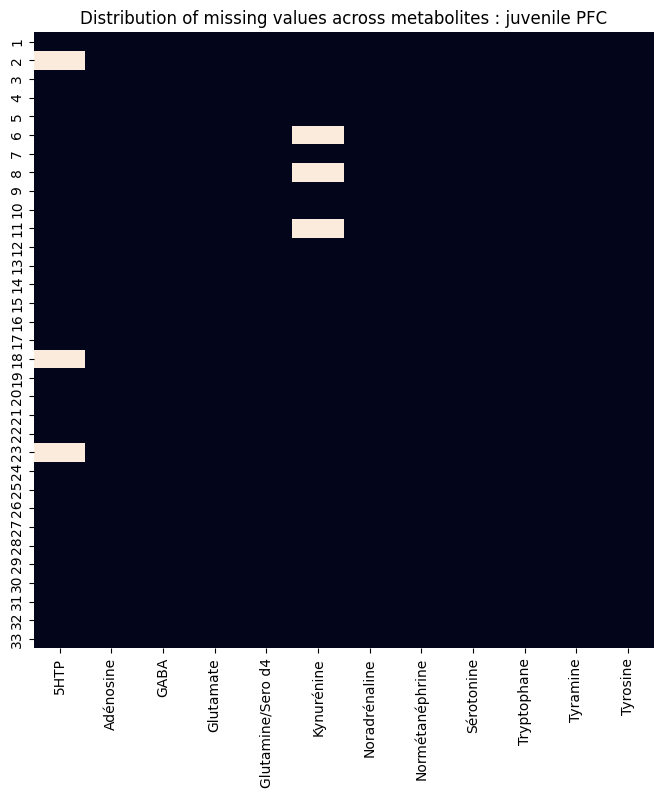

In [92]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_pfc.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile PFC")
plt.show()

In [93]:
print("Information about the Individuals who have missing values : PFC juv")
print(X_juv_pfc[X_juv_pfc.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : PFC juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  2 | nan       |     0.114   |  4.946 |       3.372 |              353.2  |    0.000348  |          0.4457 |            1.248  |      0.2482  |        1.621  |    0.02929 |      9.92  |
|  6 |   0.07679 |     0.06489 |  4.35  |       3.066 |               26.69 |  nan         |          0.4418 |            0.866  |      0.2674  |        0.7045 |    0.08121 |      5.788 |
|  8 |   0.05436 |     0.04628 |  2.341 |       1.479 |               14.08 |  nan         |          0.2165 |            0.4885 |      0.09258 |        0.448  |    0.0355  |      

---

#### For the HIP

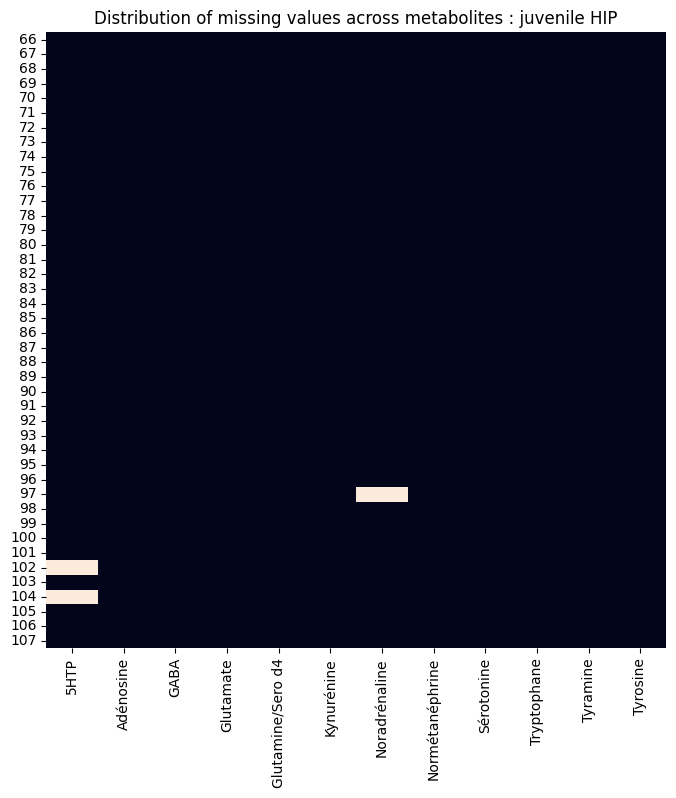

In [94]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_hip.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile HIP")
plt.show()

In [95]:
print("Information about the Individuals who have missing values : HIP juv")
print(X_juv_hip[X_juv_hip.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : HIP juv
|     |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|----:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  97 |   0.03652 |      0.1513 |  4.149 |       2.817 |              209.8  |    0.0003631 |        nan      |            0.9053 |       0.1095 |        3.502  |     0.2702 |     17.31  |
| 102 | nan       |      0.3103 |  4.02  |       2.682 |               84.33 |    0.0003547 |          0.312  |            0.7644 |       0.2293 |        0.7045 |     0.3007 |      5.821 |
| 104 | nan       |      0.1994 |  3.526 |       2.275 |               91.51 |    0.0002266 |          0.2811 |            0.6544 |       0.2525 |        5.527  |     0.2244 | 

---

#### For the STR

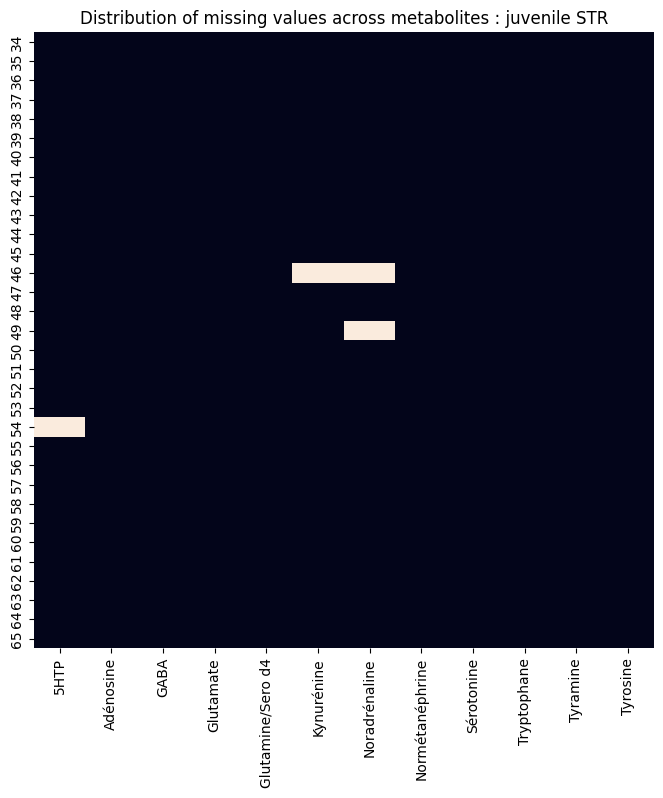

In [96]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_str.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile STR")
plt.show()

In [97]:
print("Information about the Individuals who have missing values : STR juv")
print(X_juv_str[X_juv_str.isna().any(axis=1)].to_markdown())

Information about the Individuals who have missing values : STR juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
| 46 |   0.05638 |      0.6234 |  3.645 |       2.412 |               37.69 |  nan         |       nan       |            0.2305 |       0.2553 |         1.509 |    0.1939  |      5.732 |
| 49 |   0.04216 |      0.5245 |  3.43  |       2.452 |               38.49 |    9.549e-05 |       nan       |            0.2024 |       0.134  |         1.583 |    0.09083 |      7.25  |
| 54 | nan       |      2.587  |  7.975 |       3.185 |              164.7  |    0.0002746 |         0.09882 |            0.3882 |       0.2074 |         2.63  |    0.2646  |      

#### Transformation Log 

<span style="color:yellow"> Apply a log(1+x) transformation to reduce skewness </span>


In [98]:
X_juv_pfc_log = np.log1p(X_juv_pfc)
X_juv_hip_log = np.log1p(X_juv_hip)
X_juv_str_log = np.log1p(X_juv_str)

## Analysis

### Principal Component Analysis (PCA)

---

#### For the PFC

<span style="color:yellow"> Missing values were imputed using the median value of each metabolite, followed by z-score normalization to center and scale all features prior to analysis.

In [99]:
imputer = SimpleImputer(strategy="median")
X_juv_pfc_imp = imputer.fit_transform(X_juv_pfc_log)
scaler = StandardScaler()
X_juv_pfc_scaled = scaler.fit_transform(X_juv_pfc_imp)

<span style="color:yellow"> The values used for the imputation are : 

In [100]:
missing_cols = X_juv_pfc_log.columns[X_juv_pfc_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_pfc_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP          0.062893
Kynurénine    0.000224
dtype: float64


<span style="color:yellow">  Here we apply PCA to the standardized PFC dataset and retain the first 10 principal components to know more about the explained variance

In [101]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_pfc_scaled1 = X_juv_pfc_scaled.copy()
X_juv_pfc_pca_all = pca1.fit_transform(X_juv_pfc_scaled1)

<span style="color:yellow">  Visualisation of the Variance explained by Each Principal Component. 

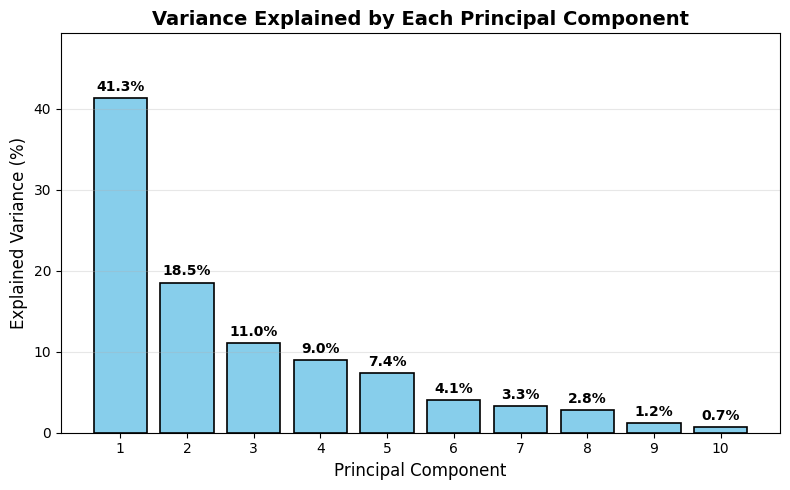

In [102]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

 <span style="color:yellow"> Now to know how many Principal Components we need to obtain at least 80% of explained variance.

In [103]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 5 principal components are required which sum up to 87.31%.


 <span style="color:yellow">Here we apply PCA to the standardized PFC dataset and retain the first 3 principal components for our analysis

In [104]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_pfc_pca = pca.fit_transform(X_juv_pfc_scaled)

In [105]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.4130362343470667,
 PCA2 : 0.18540285884753213 
 PCA3 : 0.11045194762258333 
And the sum is: 0.7088910408171822


 <span style="color:yellow"> Now to have a visualtion of the PCA projection of PFC samples on the first two principal components

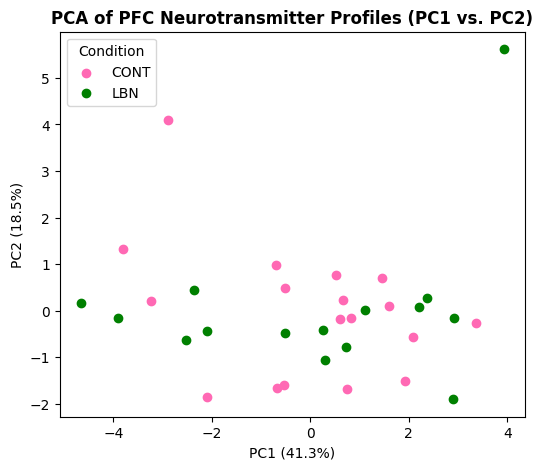

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_pfc_pca[Y_juv_pfc == 0, 0],
    X_juv_pfc_pca[Y_juv_pfc == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_pfc_pca[Y_juv_pfc == 1, 0],
    X_juv_pfc_pca[Y_juv_pfc == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of PFC Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

 <span style="color:yellow"> Create a 3D PCA score plot with projection ("needle") lines extending from each sample to the base plane to facilitate the visualization of sample positions in three-dimensional space.

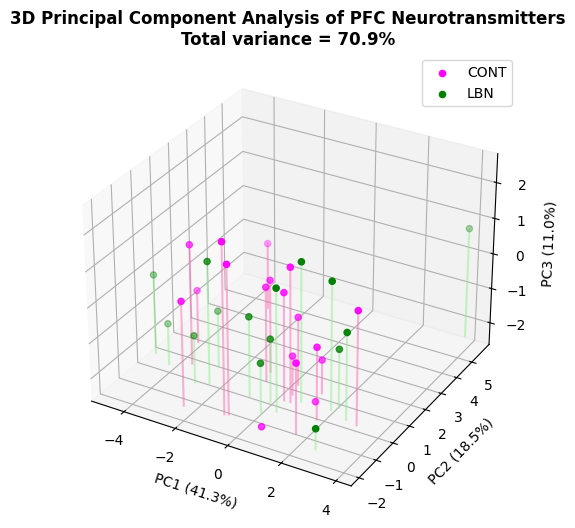

In [107]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_pfc_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_pfc_pca[Y_juv_pfc==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_pfc_pca[Y_juv_pfc==0,0],
    X_juv_pfc_pca[Y_juv_pfc==0,1],
    X_juv_pfc_pca[Y_juv_pfc==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_pfc_pca[Y_juv_pfc==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_pfc_pca[Y_juv_pfc==1,0],
    X_juv_pfc_pca[Y_juv_pfc==1,1],
    X_juv_pfc_pca[Y_juv_pfc==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of PFC Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

 <span style="color:yellow"> Now we will create a 3D PCA score plot of the PFC neurotransmitter data to visualize the distribution of samples from the CONT and LBN groups along the first three principal components.

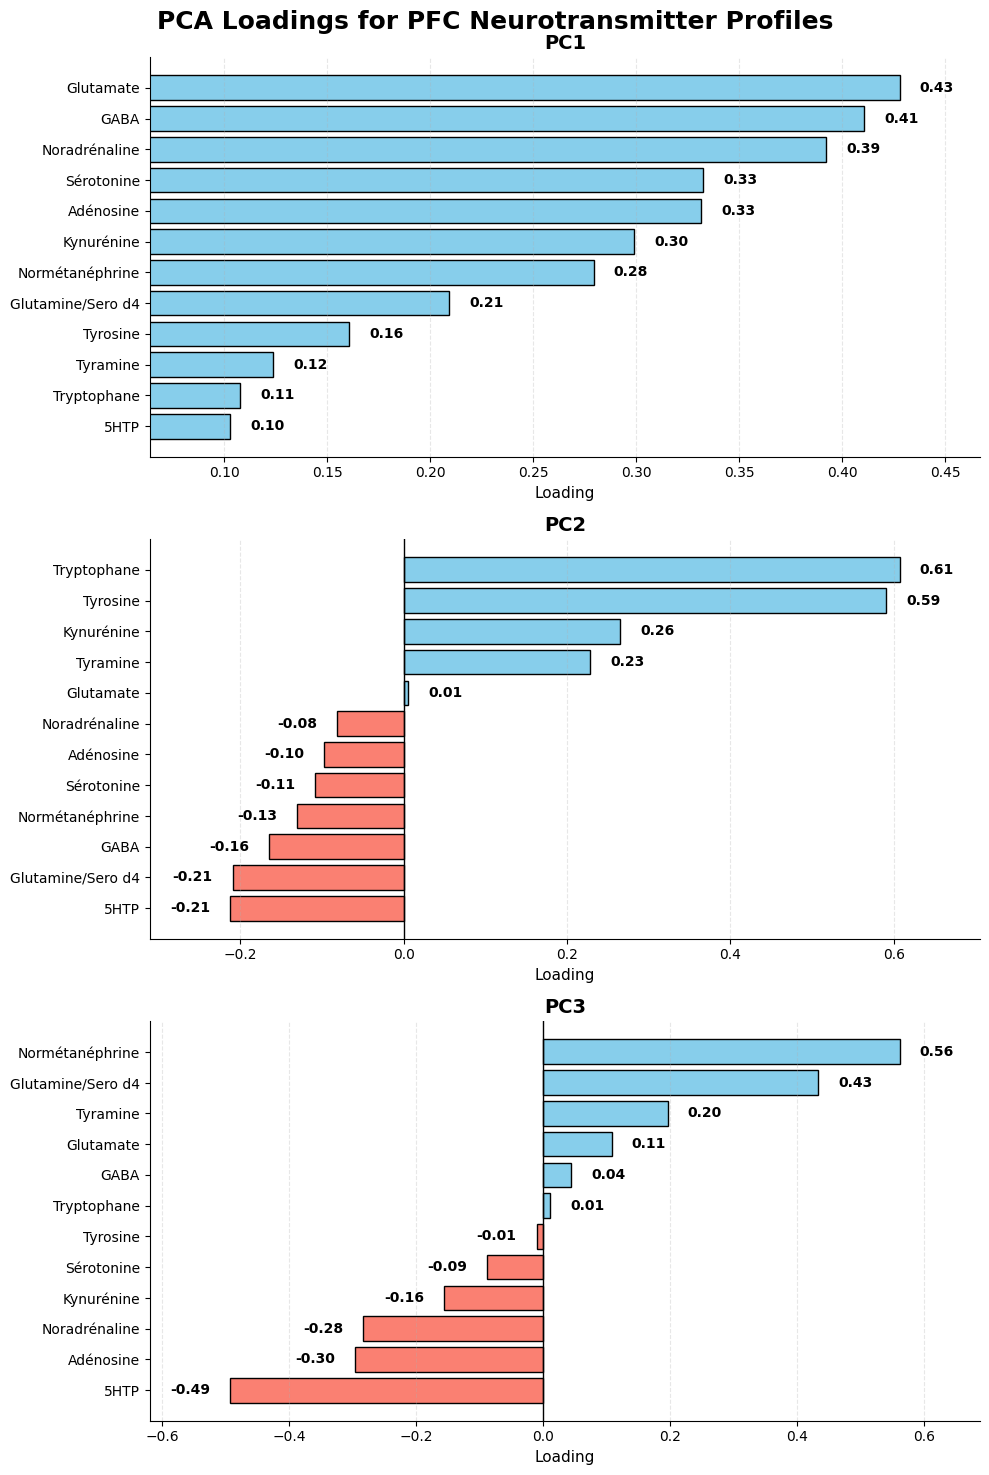

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_juv_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for PFC Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_pfc.columns):
    ax = axes[i]
    values = loadings_pfc[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

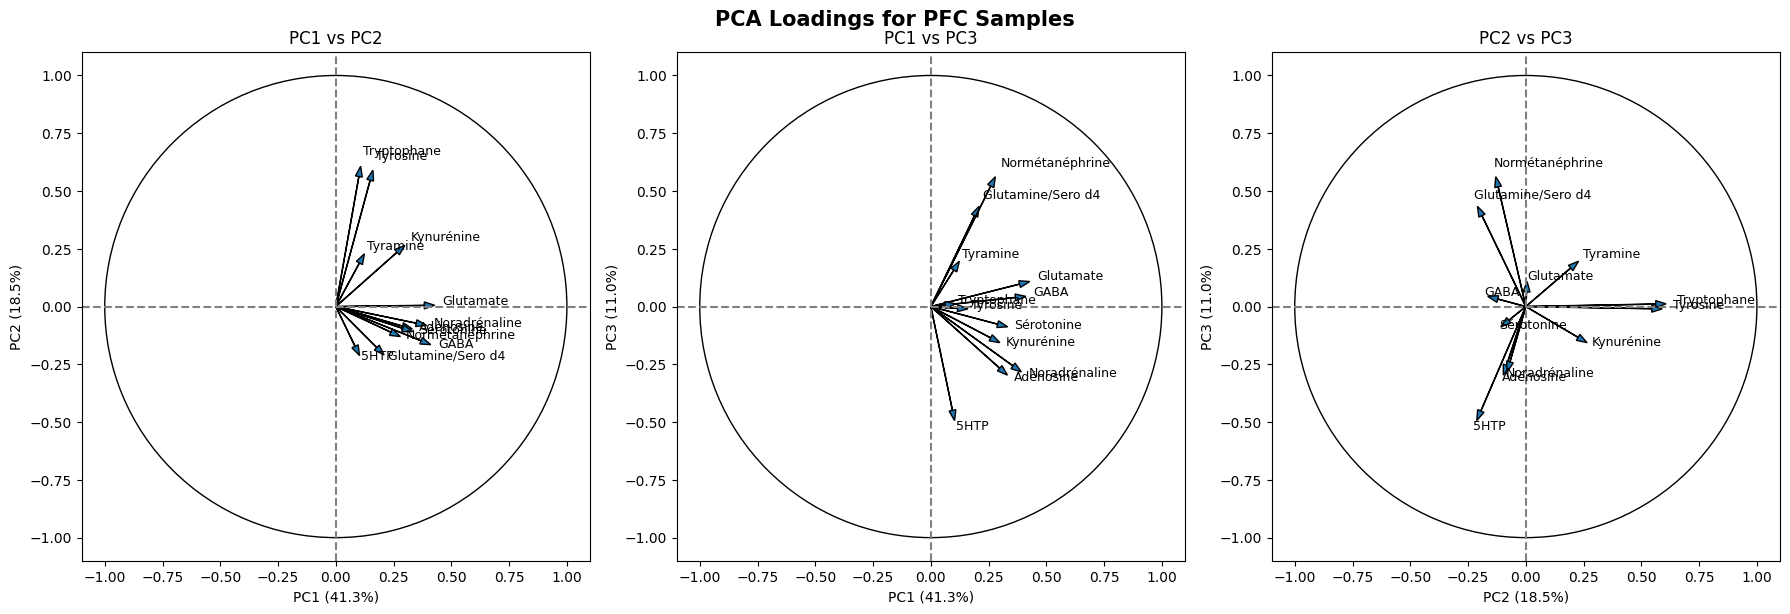

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_juv_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_pfc.index:

        x = loadings_pfc.loc[nt, pcx]
        y = loadings_pfc.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the HIP 

In [110]:
imputer = SimpleImputer(strategy="median")
X_juv_hip_imp = imputer.fit_transform(X_juv_hip_log)
scaler = StandardScaler()
X_juv_hip_scaled = scaler.fit_transform(X_juv_hip_imp)

In [111]:
missing_cols = X_juv_hip_log.columns[X_juv_hip_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_hip_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP             0.056503
Noradrénaline    0.385194
dtype: float64


In [112]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_hip_scaled1 = X_juv_hip_scaled.copy()
X_juv_hip_pca_all = pca1.fit_transform(X_juv_hip_scaled1)

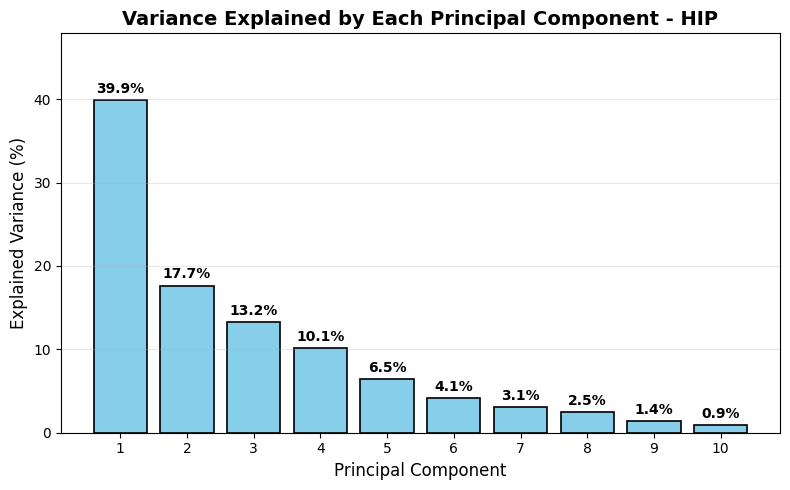

In [113]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - HIP",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [114]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 4 principal components are required which sum up to 80.91%.


In [115]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_hip_pca = pca.fit_transform(X_juv_hip_scaled)

In [116]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.39891286855956976,
 PCA2 : 0.17653186709763227 
 PCA3 : 0.13221243840745986 
And the sum is: 0.7076571740646619


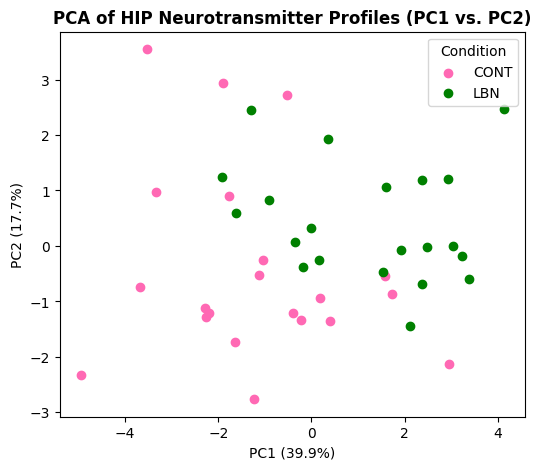

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_hip_pca[Y_juv_hip == 0, 0],
    X_juv_hip_pca[Y_juv_hip == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_hip_pca[Y_juv_hip == 1, 0],
    X_juv_hip_pca[Y_juv_hip == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of HIP Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

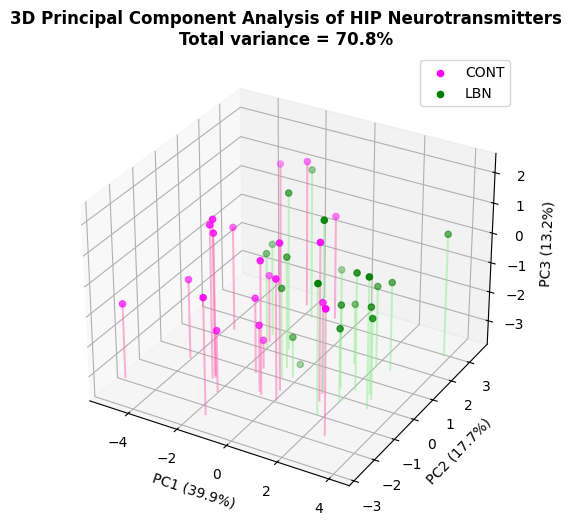

In [118]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_hip_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_hip_pca[Y_juv_hip==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_hip_pca[Y_juv_hip==0,0],
    X_juv_hip_pca[Y_juv_hip==0,1],
    X_juv_hip_pca[Y_juv_hip==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_hip_pca[Y_juv_hip==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_hip_pca[Y_juv_hip==1,0],
    X_juv_hip_pca[Y_juv_hip==1,1],
    X_juv_hip_pca[Y_juv_hip==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of HIP Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

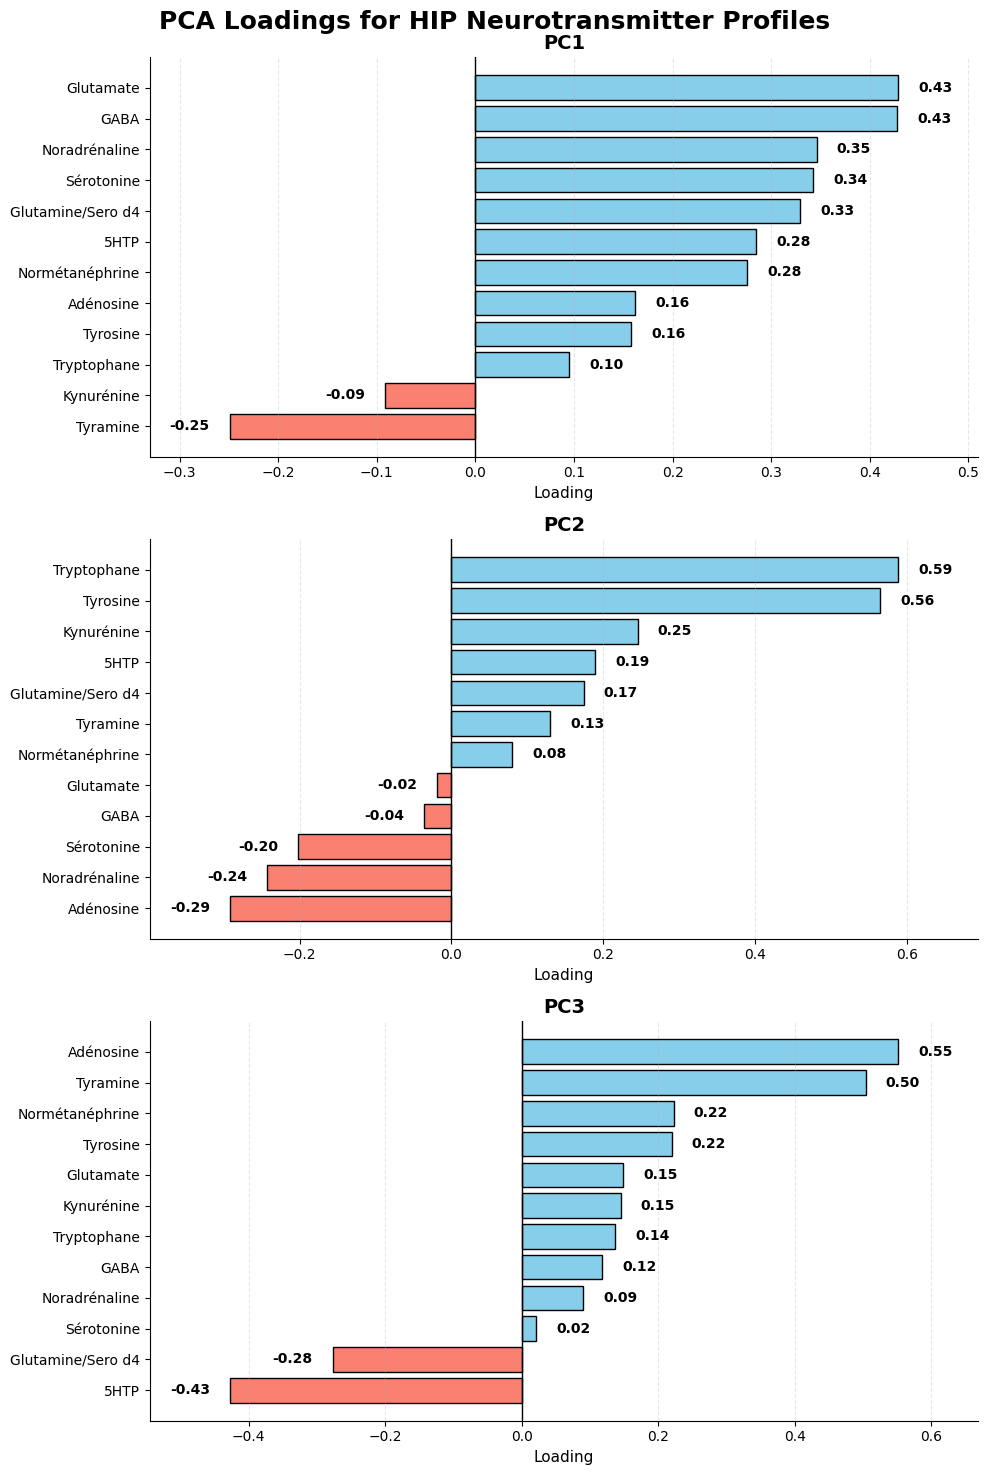

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_juv_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for HIP Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_hip.columns):
    ax = axes[i]
    values = loadings_hip[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

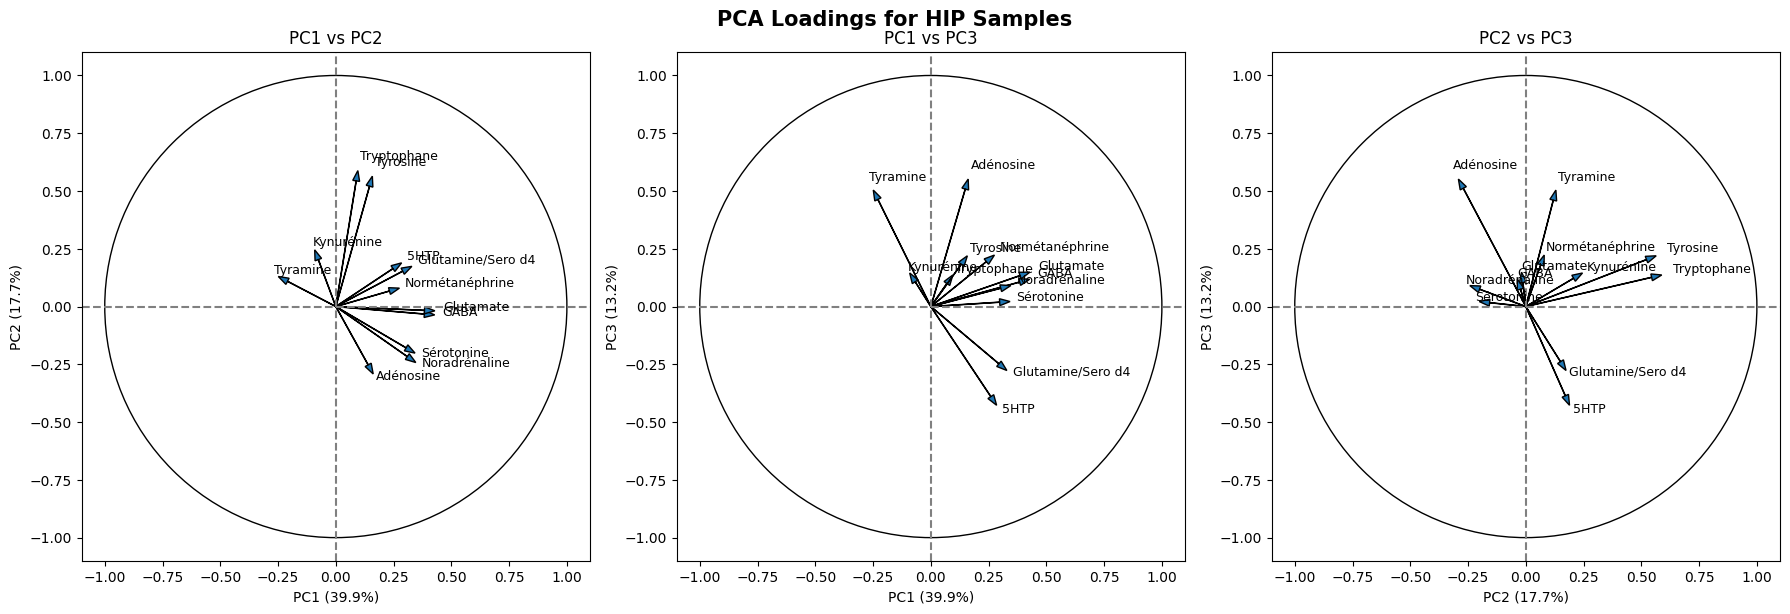

In [120]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_juv_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_hip.index:

        x = loadings_hip.loc[nt, pcx]
        y = loadings_hip.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the STR

In [121]:
imputer = SimpleImputer(strategy="median")
X_juv_str_imp = imputer.fit_transform(X_juv_str_log)
scaler = StandardScaler()
X_juv_str_scaled = scaler.fit_transform(X_juv_str_imp)

In [122]:
missing_cols = X_juv_str_log.columns[X_juv_str_log.isna().any()]
median_used = pd.Series(
    imputer.statistics_,
    index=X_juv_str_log.columns
).loc[missing_cols]

print(f"The Median values used for imputation:\n{median_used}")

The Median values used for imputation:
5HTP             0.099302
Kynurénine       0.000239
Noradrénaline    0.370767
dtype: float64


In [123]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_juv_str_scaled1 = X_juv_str_scaled.copy()
X_juv_str_pca_all = pca1.fit_transform(X_juv_str_scaled1)

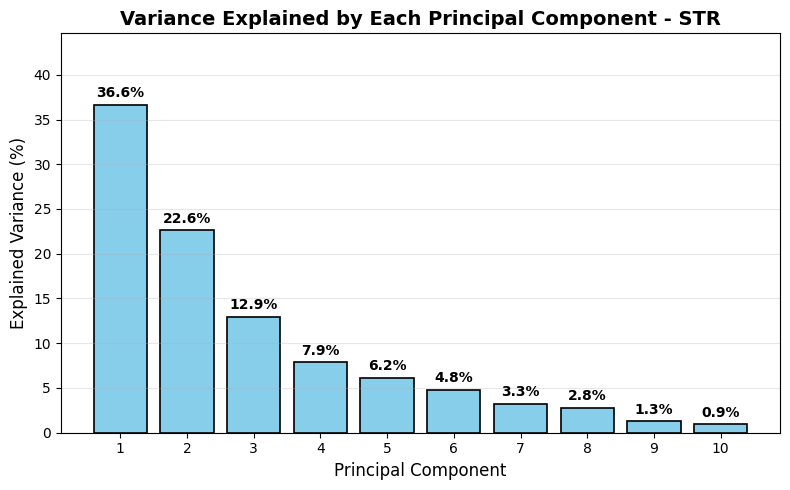

In [124]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - STR",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [125]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 4 principal components are required which sum up to 80.09%.


In [126]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_juv_str_pca = pca.fit_transform(X_juv_str_scaled)

In [127]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.3662983757390585,
 PCA2 : 0.22649515403981352 
 PCA3 : 0.12935161149644325 
And the sum is: 0.7221451412753153


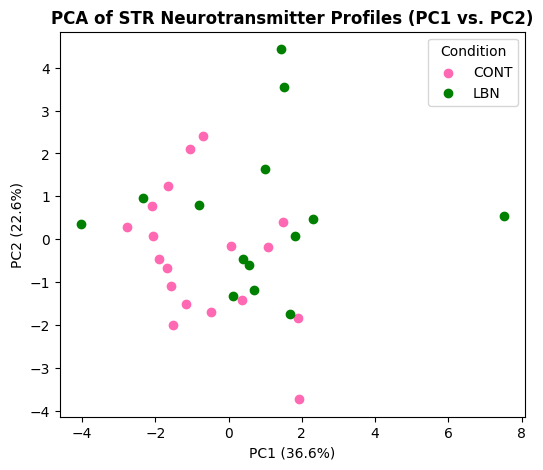

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_juv_str_pca[Y_juv_str == 0, 0],
    X_juv_str_pca[Y_juv_str == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_juv_str_pca[Y_juv_str == 1, 0],
    X_juv_str_pca[Y_juv_str == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of STR Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

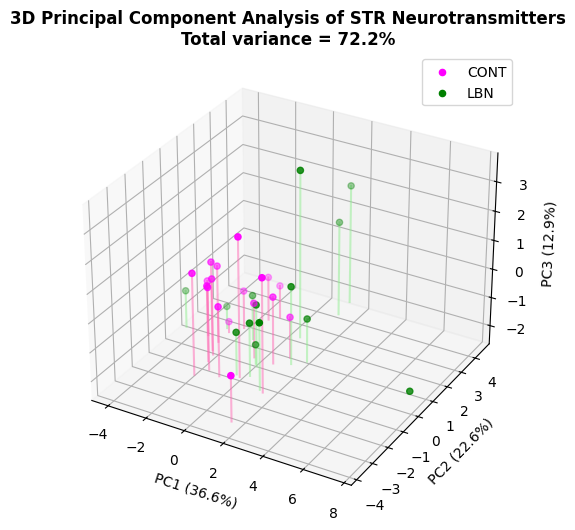

In [129]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_juv_str_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_str_pca[Y_juv_str==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_juv_str_pca[Y_juv_str==0,0],
    X_juv_str_pca[Y_juv_str==0,1],
    X_juv_str_pca[Y_juv_str==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_juv_str_pca[Y_juv_str==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_juv_str_pca[Y_juv_str==1,0],
    X_juv_str_pca[Y_juv_str==1,1],
    X_juv_str_pca[Y_juv_str==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of STR Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

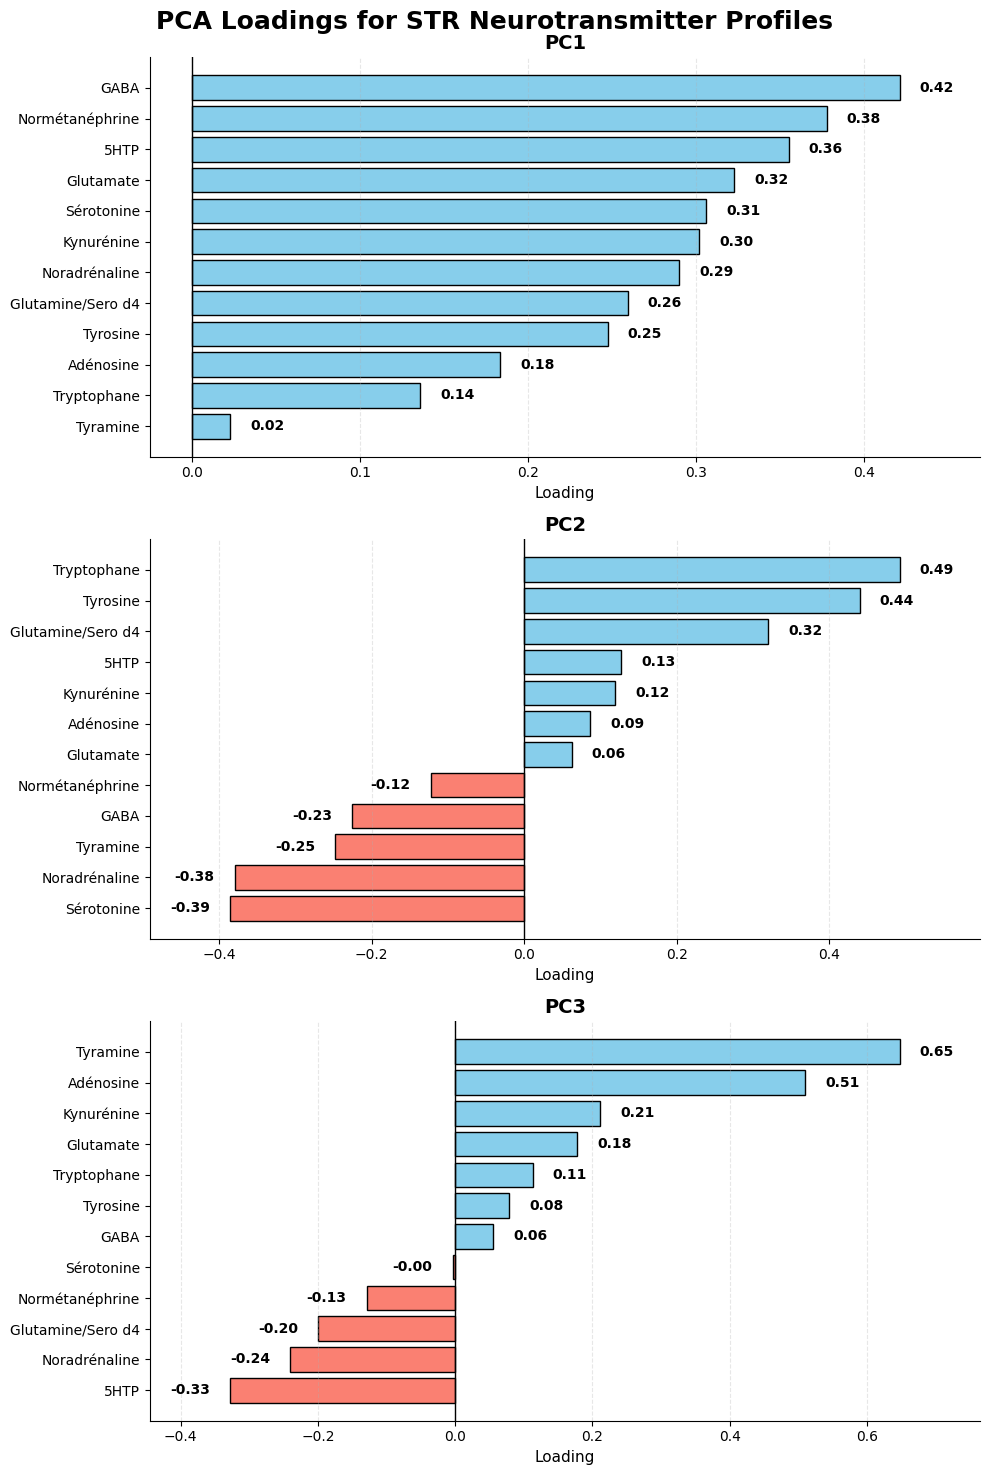

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_str = pd.DataFrame(
    pca.components_.T,
    index=X_juv_str.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for STR Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_str.columns):
    ax = axes[i]
    values = loadings_str[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

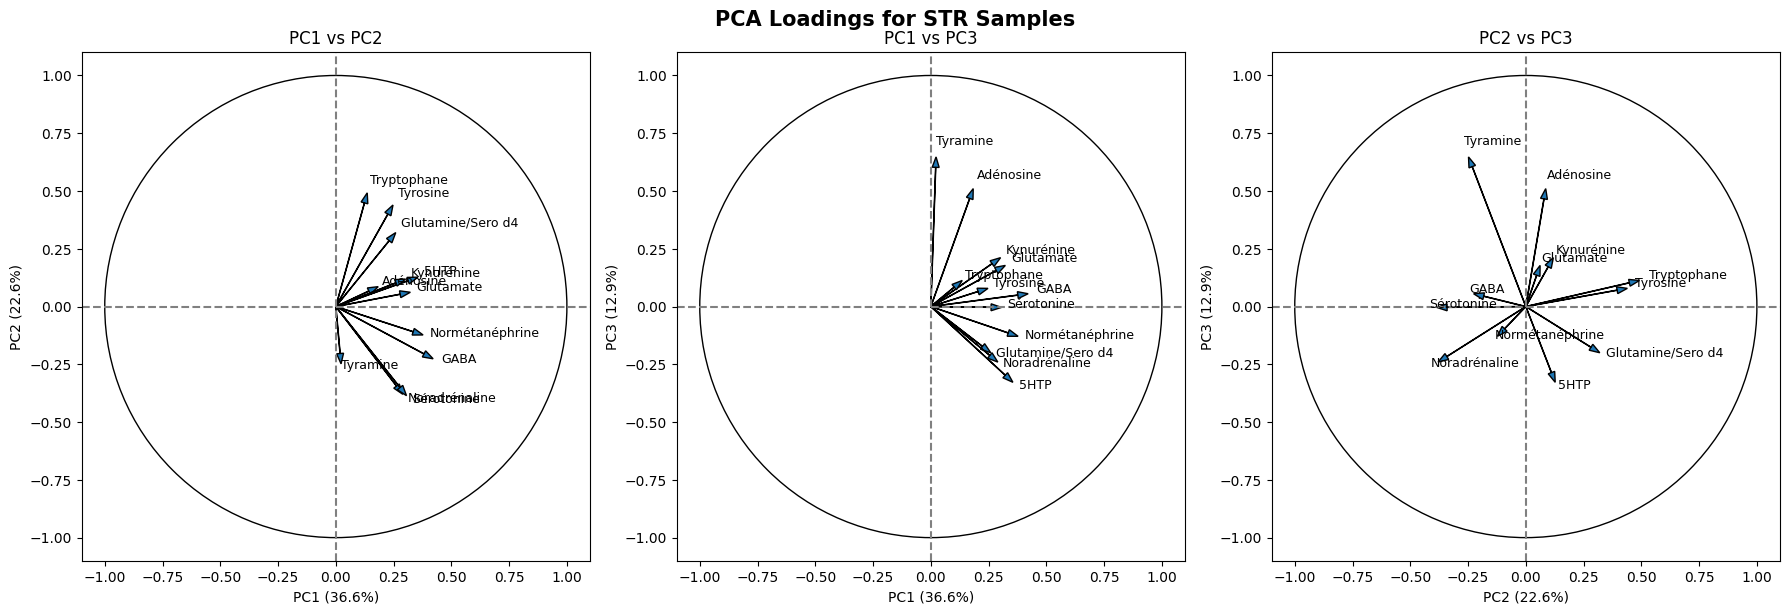

In [132]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_str = pd.DataFrame(
    pca.components_.T,
    index=X_juv_str.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for STR Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_str.index:

        x = loadings_str.loc[nt, pcx]
        y = loadings_str.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

### Hierarchical clustering

---

#### For the PFC

 <span style="color:yellow"> Hierarchical clustering was performed to explore the similarity between PFC samples based on their standardized neurotransmitter profiles

  <span style="color:yellow"> Clustering was performed using Ward's linkage and Euclidean distance. Euclidean distance measures the overall dissimilarity between samples. Ward's linkage was chosen because it minimizes the variance within clusters, resulting in compact and well-separated groups.

  <span style="color:yellow"> The resulting heatmap visualizes the clustering of samples and neurotransmitters, with a legend indicating the experimental groups (CONT and LBN).

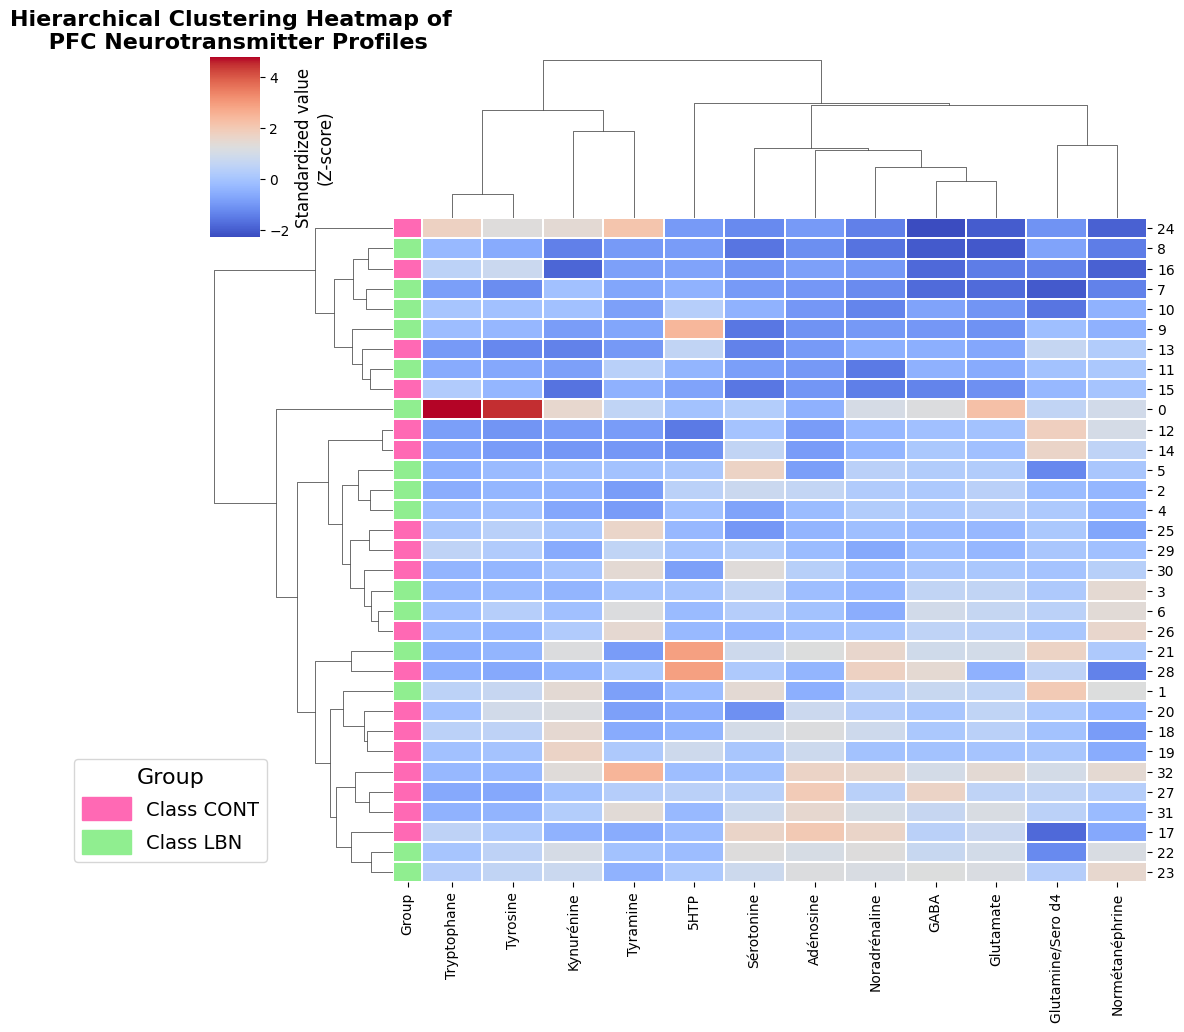

In [137]:
# Impute missing values using the median and standardize the data
# before hierarchical clustering
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_pfc_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Assign colors to each sample according to its experimental group
row_colors = Y_juv_pfc.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

# Generate a hierarchical clustering heatmap using Ward's linkage
# and Euclidean distance on the standardized neurotransmitter data
g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_pfc_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

# Create and display a legend for the experimental groups
legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,
    title_fontsize=16,
    handlelength=2.5,
    handleheight=1.5
)

# Customize the color bar and figure title
g.cax.set_ylabel("Standardized value\n(Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n PFC Neurotransmitter Profiles", fontsize=16, fontweight="bold")

plt.show()

 <span style="color:yellow"> Each sample was assigned to one of two clusters based on the hierarchical clustering results.
 A table was then created to compare the clusters with the experimental groups. This helps determine whether samples from the same group tend to cluster together or are mixed between the two clusters.

In [138]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                 4          5      9
2                14         10     24
All              18         15     33


In [140]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.2754246282243953


---

#### For the HIP

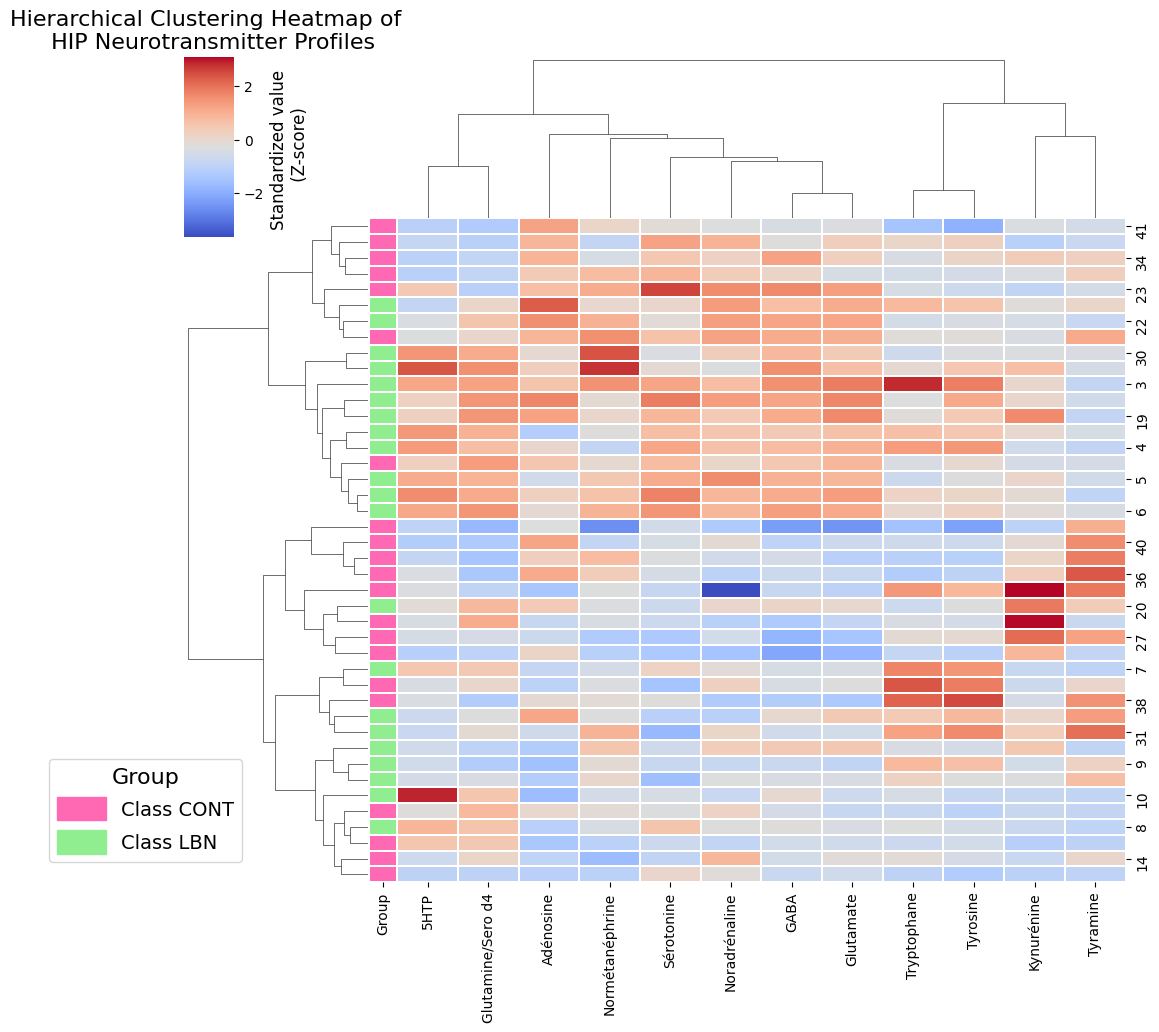

In [142]:
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_hip_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

row_colors = Y_juv_hip.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_hip_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n HIP Neurotransmitter Profiles", fontsize=16)
plt.show()

In [143]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1              7       12     19
2             14        9     23
All           21       21     42


In [144]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.21348586142394596


---

#### For the STR

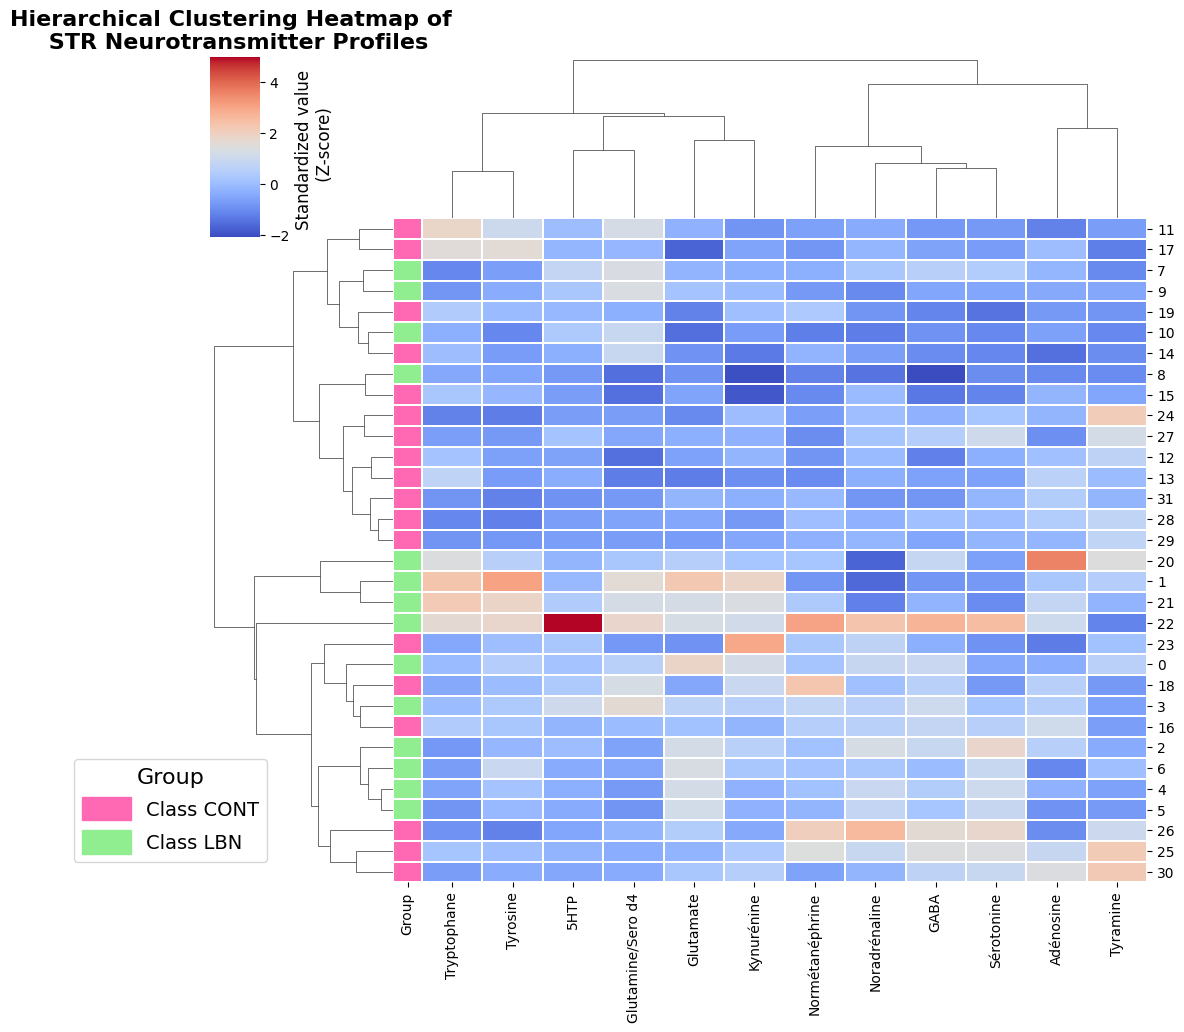

In [149]:
import matplotlib.patches as mpatches

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_juv_str_log)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

row_colors = Y_juv_str.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_str_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n STR Neurotransmitter Profiles", fontsize=16, fontweight="bold")
plt.show()

In [150]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_str.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                12          4     16
2                 6         10     16
All              18         14     32


In [151]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.19378549380974514


### Logistic Regression

--- 

#### For the PFC

In [ ]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc"
)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [ ]:
log_pipe.fit(X_juv_pfc_log, Y_juv_pfc)

coef = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for PFC")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_pfc_log,
        Y_juv_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.impute import SimpleImputer


selected = [
    "Normétanéphrine",
    "5HTP",
    "Glutamate",
    "Tyrosine",
    "Kynurénine",
    "Sérotonine"
]

# log-transformed data
X_small = X_juv_pfc_log[selected]

# median imputation
imp = SimpleImputer(strategy="median")
X_small = pd.DataFrame(
    imp.fit_transform(X_small),
    columns=selected
)

# add intercept
X_sm = sm.add_constant(X_small)

# logistic regression
model = sm.Logit(Y_juv_pfc, X_sm)

result = model.fit(method="bfgs")

print(result.summary())


---

#### For the HIP

In [ ]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc"
)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

In [ ]:
log_pipe.fit(X_juv_hip_log, Y_juv_hip)

coef = pd.DataFrame({
    "NT": X_juv_hip_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for HIP")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_hip_log,
        Y_juv_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.impute import SimpleImputer


selected = [
    "5HTP",
    "Glutamate",
    "Tyrosine",
    "GABA",
    "Normétanéphrine",
    "Glutamine/Sero d4"
]

# log-transformed data
X_small = X_juv_hip_log[selected]

# median imputation
imp = SimpleImputer(strategy="median")
X_small = pd.DataFrame(
    imp.fit_transform(X_small),
    columns=selected
)

# add intercept
X_sm = sm.add_constant(X_small)

X_sm = X_sm.reset_index(drop=True)
Y_juv_hip = Y_juv_hip.reset_index(drop=True)
# logistic regression
model = sm.Logit(Y_juv_hip, X_sm)

result = model.fit(method="bfgs")

print(result.summary())


---

#### For the STR

In [ ]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_str = cross_val_score(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc"
)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - STR")
plt.show()

In [ ]:
log_pipe.fit(X_juv_str_log, Y_juv_str)

coef = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for STR")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_str_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_str_log,
        Y_juv_str,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.impute import SimpleImputer


selected = [
    "5HTP",
    "Tyrosine",
    "Adénosine",
    "GABA",
    "Glutamine/Sero d4",
    "Sérotonine"
]

# log-transformed data
X_small = X_juv_str_log[selected]

# median imputation
imp = SimpleImputer(strategy="median")
X_small = pd.DataFrame(
    imp.fit_transform(X_small),
    columns=selected
)

# add intercept
X_sm = sm.add_constant(X_small)

X_sm = X_sm.reset_index(drop=True)
Y_juv_str = Y_juv_str.reset_index(drop=True)
# logistic regression
model = sm.Logit(Y_juv_str, X_sm)

result = model.fit(method="bfgs")

print(result.summary())


### Random Forest

---

#### For the PFC

In [ ]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=2, #Each tree can only make 2 splits.
    min_samples_leaf=4, #Minimum animals at the end of a branch.
    min_samples_split=8, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc",
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1

)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

In [ ]:
rf_pipe.fit(X_juv_pfc_log, Y_juv_pfc)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - PFC")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(X_juv_pfc_log)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_pfc_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC")
plt.tight_layout()
plt.show()

code supp

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [2, 3],
    "rf__min_samples_leaf": [2, 4],
    "rf__min_samples_split": [4, 8]
}

inner_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=inner_cv,
    scoring="roc_auc",
    n_jobs=-1
)

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    grid,
    X_juv_pfc_log,      # change for HIP or STR
    Y_juv_pfc,
    cv=outer_cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Tuned Random Forest =====")
print(f"Mean AUC = {scores.mean():.3f}")
print(f"SD = {scores.std():.3f}")

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.title("Random Forest ROC Curve - PFC")
plt.show()

---

#### For the HIP

In [ ]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

In [ ]:
rf_pipe.fit(X_juv_hip_log, Y_juv_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_juv_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - HIP")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(
    X_juv_hip_log
)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_hip_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - HIP")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()

---

#### For the STR

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=4,
        class_weight="balanced",
        max_features="sqrt",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print(f"Mean AUC = {scores.mean():.3f}")
print(f"SD = {scores.std():.3f}")

In [ ]:
rf_pipe.fit(X_juv_str_log, Y_juv_str)

rf = rf_pipe.named_steps["rf"]

# Variable importance
rf_importance = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - STR")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Impute missing values
X_imp = rf_pipe.named_steps["imputer"].transform(
    X_juv_str_log
)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_juv_str_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - STR")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)

plt.title("Random Forest ROC Curve - STR")
plt.show()